# Predicting Student Dropout — Exploratory Data Analysis

**Dataset:** [Predict Students' Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) (UCI ML Repository) — 4,424 students enrolled in different undergraduate degrees at a Portuguese higher-education institution. Each row contains enrollment-time, first-semester, and second-semester information for one student. The `Target` column tells us whether the student **Dropout**, stayed **Enrolled**, or **Graduate**d. The primary early-warning model will use only enrollment-time and first-semester variables; second-semester variables are retained here for descriptive EDA but excluded from primary modeling as temporal leakage.

This notebook follows the same EDA workflow our professor used in the [Case Study - Regression](https://github.com/chaklam-silpasuwanchai/Python-for-Machine-Learning/blob/main/00%20-%20Case%20Study/01%20-%20Case%20Study%20-%20Regression.ipynb) notebook:

1. Load the data and get an overview (`shape`, `dtypes`, `describe`, `info`)
2. Clean/rename columns
3. Check missing values & duplicates
4. Univariate analysis (one variable at a time — distributions, counts)
5. Multivariate analysis (relationships between variables, especially vs. our `Target`)
6. Correlation matrix
7. Outlier detection
8. Wrap up with the key takeaways we'll carry into feature engineering & modeling

## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

np.__version__, pd.__version__, sns.__version__, matplotlib.__version__

('2.5.3', '3.0.5', '0.13.2', '3.11.2')

## 1. Load data

Loading the data set.

In [2]:
df = pd.read_csv('data/dropout_data.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1.0,17.0,5.0,171.0,1.0,1.0,122.0,1.0,19.0,12.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,10.8,1.4,1.74,Dropout
1,1.0,15.0,1.0,9254.0,1.0,1.0,160.0,1.0,1.0,3.0,...,0.0,6.0,6.0,6.0,13.666667,0.0,13.9,-0.3,0.79,Graduate
2,1.0,1.0,5.0,9070.0,1.0,1.0,122.0,1.0,37.0,37.0,...,0.0,6.0,0.0,0.0,0.000000,0.0,10.8,1.4,1.74,Dropout
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,...,0.0,6.0,10.0,5.0,12.400000,0.0,9.4,-0.8,-3.12,Graduate
4,2.0,39.0,1.0,8014.0,0.0,1.0,100.0,1.0,37.0,38.0,...,0.0,6.0,6.0,6.0,13.000000,0.0,13.9,-0.3,0.79,Graduate


 how many students (rows) and how many features (columns) are we working with?

In [3]:
df.shape

(4424, 37)

`.describe()` to check qucik summary statistic 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


`.info()` to check the dtype of every column and how many non-null values it has just to quick check how many null values

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   float64
 1   Application mode                                4424 non-null   float64
 2   Application order                               4424 non-null   float64
 3   Course                                          4424 non-null   float64
 4   Daytime/evening attendance	                     4424 non-null   float64
 5   Previous qualification                          4424 non-null   float64
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   float64
 8   Mother's qualification                          4424 non-null   float64
 9   Father's qualification                          4424

In [6]:
df.columns # just to check the colum name

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

## 2. Exploratory Data Analysis

### Renaming & cleaning columns

The raw column names came straight from the UCI dataset: mixed case, spaces, apostrophes, and even a stray tab character on `'Daytime/evening attendance'`. Messy names make code error-prone (`df['Daytime/evening attendance\t']` is easy to typo). 

In [7]:
def clean_col(c):
    c = c.strip()                      # drop leading/trailing whitespace (catches that stray '\t')
    c = c.replace("'", "")             # Mother's -> Mothers
    c = c.replace('/', '_').replace('(', '').replace(')', '')
    c = c.replace('-', '_')
    c = '_'.join(c.split())            # collapse internal whitespace, join with _
    return c.lower()

rename_map = {c: clean_col(c) for c in df.columns}
rename_map

{'Marital status': 'marital_status',
 'Application mode': 'application_mode',
 'Application order': 'application_order',
 'Course': 'course',
 'Daytime/evening attendance\t': 'daytime_evening_attendance',
 'Previous qualification': 'previous_qualification',
 'Previous qualification (grade)': 'previous_qualification_grade',
 'Nacionality': 'nacionality',
 "Mother's qualification": 'mothers_qualification',
 "Father's qualification": 'fathers_qualification',
 "Mother's occupation": 'mothers_occupation',
 "Father's occupation": 'fathers_occupation',
 'Admission grade': 'admission_grade',
 'Displaced': 'displaced',
 'Educational special needs': 'educational_special_needs',
 'Debtor': 'debtor',
 'Tuition fees up to date': 'tuition_fees_up_to_date',
 'Gender': 'gender',
 'Scholarship holder': 'scholarship_holder',
 'Age at enrollment': 'age_at_enrollment',
 'International': 'international',
 'Curricular units 1st sem (credited)': 'curricular_units_1st_sem_credited',
 'Curricular units 1st sem

In [8]:
df = df.rename(columns=rename_map)
df.columns.tolist()

['marital_status',
 'application_mode',
 'application_order',
 'course',
 'daytime_evening_attendance',
 'previous_qualification',
 'previous_qualification_grade',
 'nacionality',
 'mothers_qualification',
 'fathers_qualification',
 'mothers_occupation',
 'fathers_occupation',
 'admission_grade',
 'displaced',
 'educational_special_needs',
 'debtor',
 'tuition_fees_up_to_date',
 'gender',
 'scholarship_holder',
 'age_at_enrollment',
 'international',
 'curricular_units_1st_sem_credited',
 'curricular_units_1st_sem_enrolled',
 'curricular_units_1st_sem_evaluations',
 'curricular_units_1st_sem_approved',
 'curricular_units_1st_sem_grade',
 'curricular_units_1st_sem_without_evaluations',
 'curricular_units_2nd_sem_credited',
 'curricular_units_2nd_sem_enrolled',
 'curricular_units_2nd_sem_evaluations',
 'curricular_units_2nd_sem_approved',
 'curricular_units_2nd_sem_grade',
 'curricular_units_2nd_sem_without_evaluations',
 'unemployment_rate',
 'inflation_rate',
 'gdp',
 'target']

A couple of names are still slightly odd because the source data has them (e.g. `nacionality` is a typo baked into the original UCI dataset — we'll leave it as-is so it still matches the dataset's official documentation, but it's worth flagging for the report).

### Missing values & duplicates

Before any analysis, check for two of the most common data-quality issues: missing values and duplicate rows.

In [9]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [10]:
print('Rows with at least one missing value:', df.isna().any(axis=1).sum())
print('Fully duplicated rows:', df.duplicated().sum())

Rows with at least one missing value: 0
Fully duplicated rows: 0


### 2.1 Univariate analysis

#### Target distribution

`Target` is what we ultimately want to predict, so it's the first thing worth understanding. Is it balanced across the three classes, or skewed?

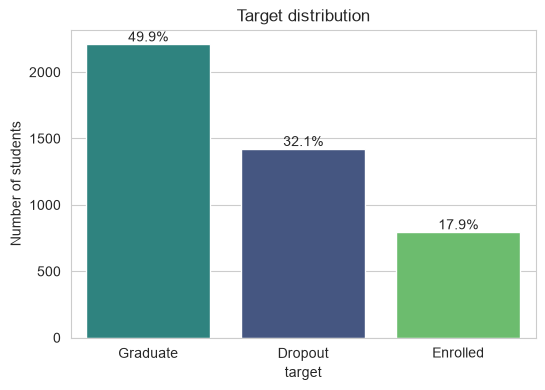

target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='target', order=df['target'].value_counts().index, hue='target', legend=False, palette='viridis')
total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title('Target distribution')
plt.ylabel('Number of students')
plt.show()

df['target'].value_counts(normalize=True).round(3)

**Reading this:** about **50% Graduate**, **32% Dropout**, and **18% Enrolled** (still studying, outcome unknown). These are the raw three-class labels. The pre-specified primary task is binary **Dropout (1) versus Graduate (0)**, excluding Enrolled because its final outcome is unresolved; a three-class or Enrolled-as-non-dropout run is sensitivity analysis only. Class-aware metrics remain necessary rather than accuracy alone.

#### Distribution of key numeric features

Two features that are usually very informative for dropout: the student's age at enrollment, and their admission grade.

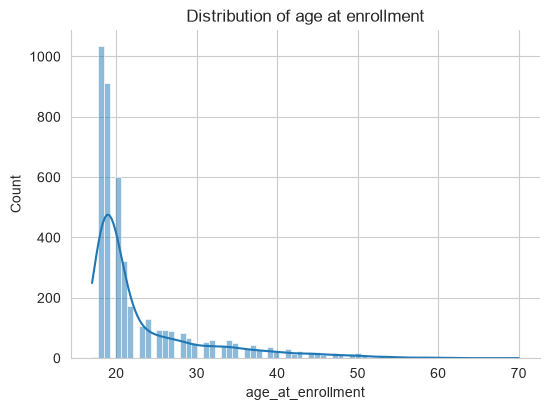

In [12]:
sns.displot(data=df, x='age_at_enrollment', kde=True, height=4, aspect=1.4)
plt.title('Distribution of age at enrollment')
plt.show()

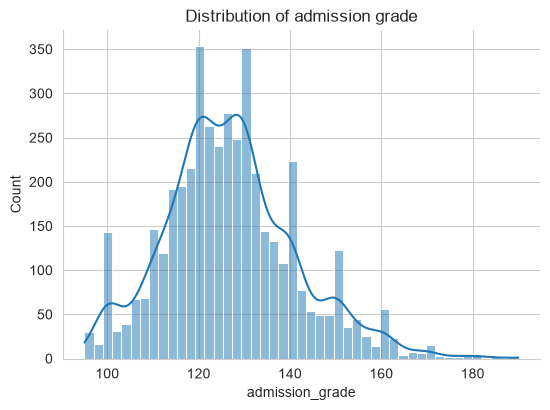

In [13]:
sns.displot(data=df, x='admission_grade', kde=True, height=4, aspect=1.4)
plt.title('Distribution of admission grade')
plt.show()

Age is heavily **right-skewed** — most students enroll around 18–20, with a long tail of older/mature students. Admission grade is roughly bell-shaped and centered around 125-ish (on whatever scale the institution uses).

The `curricular_units_*_grade` columns show how academic outcomes evolve across the year. We inspect both semesters descriptively, but only first-semester information is eligible for the primary model; second-semester grades occur after the decision point and must not be used as early-warning predictors.

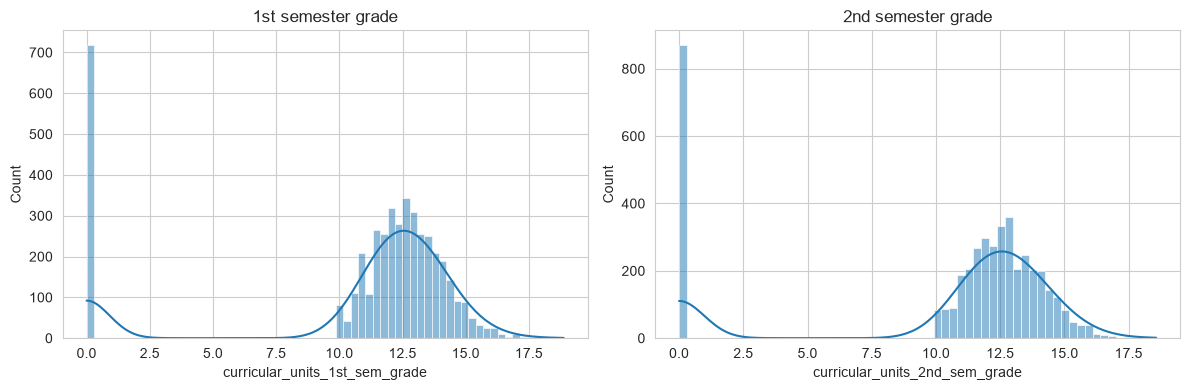

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['curricular_units_1st_sem_grade'], kde=True, ax=axes[0])
axes[0].set_title('1st semester grade')
sns.histplot(df['curricular_units_2nd_sem_grade'], kde=True, ax=axes[1])
axes[1].set_title('2nd semester grade')
plt.tight_layout()
plt.show()

Notice the spike at **0** in both — that's not a real low grade, it's students who had **no evaluations at all** that semester (often an early sign of disengagement, which usually precedes dropout). We should keep that in mind: 0 here doesn't mean 'attempted and failed everything', it can mean 'never really started'.

#### Categorical / binary feature counts

Several features are yes/no flags. Let's look at their balance in one grid.

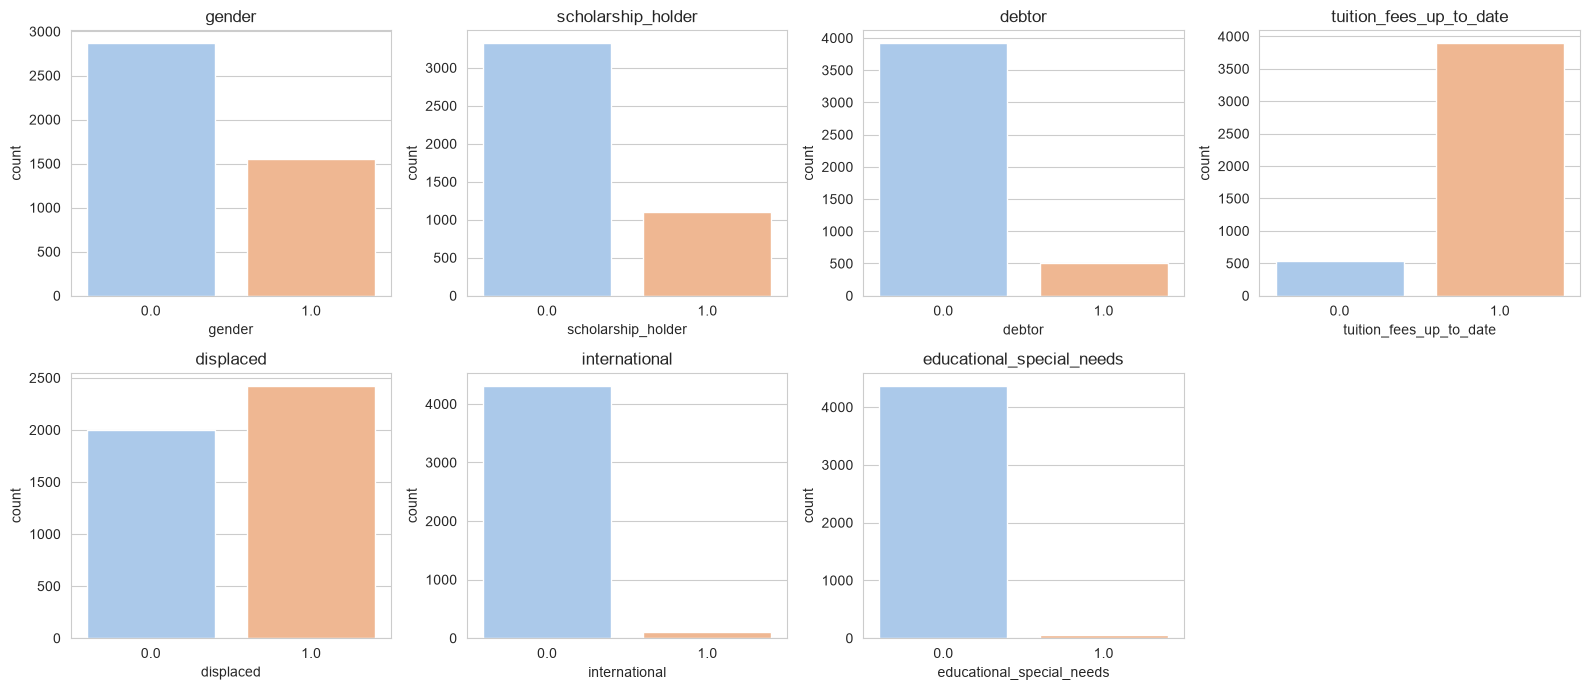

In [15]:
binary_cols = ['gender', 'scholarship_holder', 'debtor', 'tuition_fees_up_to_date',
               'displaced', 'international', 'educational_special_needs']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    sns.countplot(data=df, x=col, hue=col, legend=False, ax=axes[i], palette='pastel')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

`gender` here is coded `0`/`1` (per the UCI documentation: 1 = male, 0 = female) rather than a label — worth relabeling in a report/presentation so it's not ambiguous to readers. Most students are **not** debtors, **are** up to date on tuition, and are **not** international/displaced/scholarship holders — each of those minority groups is still large enough (hundreds of students) to analyze.

### 2.2 Multivariate analysis

Now the more interesting question: how do these features relate to `target`?

#### Boxplot: numeric feature vs. Target

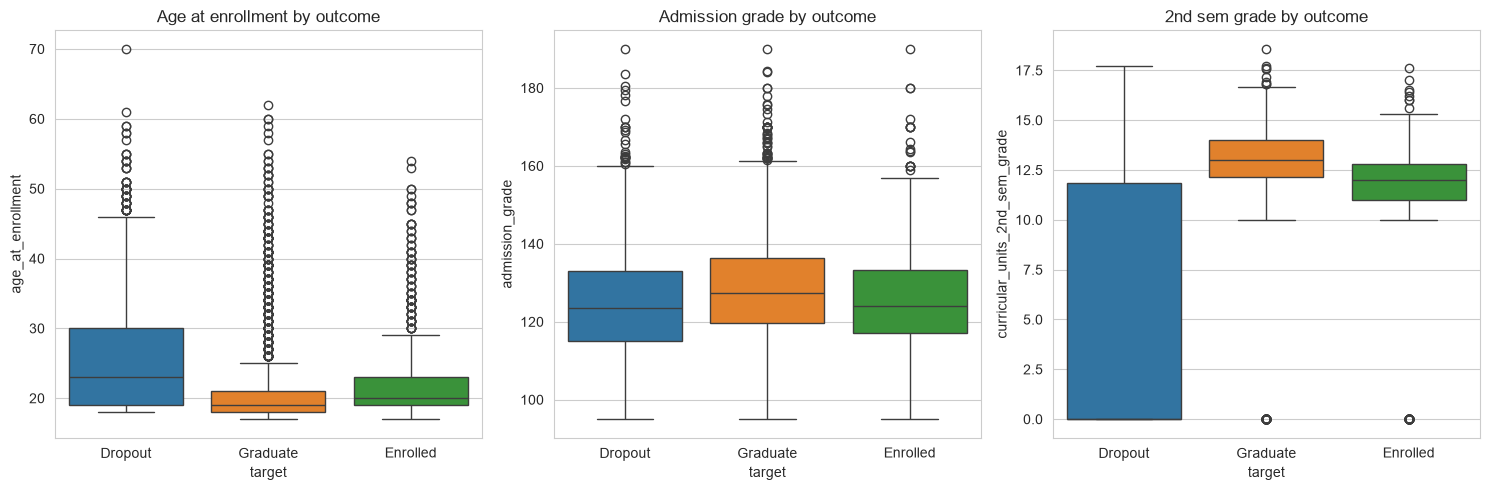

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, x='target', y='age_at_enrollment', hue='target', legend=False, ax=axes[0])
axes[0].set_title('Age at enrollment by outcome')
sns.boxplot(data=df, x='target', y='admission_grade', hue='target', legend=False, ax=axes[1])
axes[1].set_title('Admission grade by outcome')
sns.boxplot(data=df, x='target', y='curricular_units_2nd_sem_grade', hue='target', legend=False, ax=axes[2])
axes[2].set_title('2nd sem grade by outcome')
plt.tight_layout()
plt.show()

**Reading this:** Dropout students tend to be **older at enrollment** than Graduates and have a noticeably lower second-semester grade. The latter is a retrospective association, not an eligible early-warning predictor. Admission grade differs less dramatically, while first-semester performance provides the in-programme evidence available at the chosen decision point.

#### Categorical features vs. Target

For binary/categorical features, a stacked percentage bar is more informative than raw counts, since it directly shows the dropout **rate** within each group rather than group size.

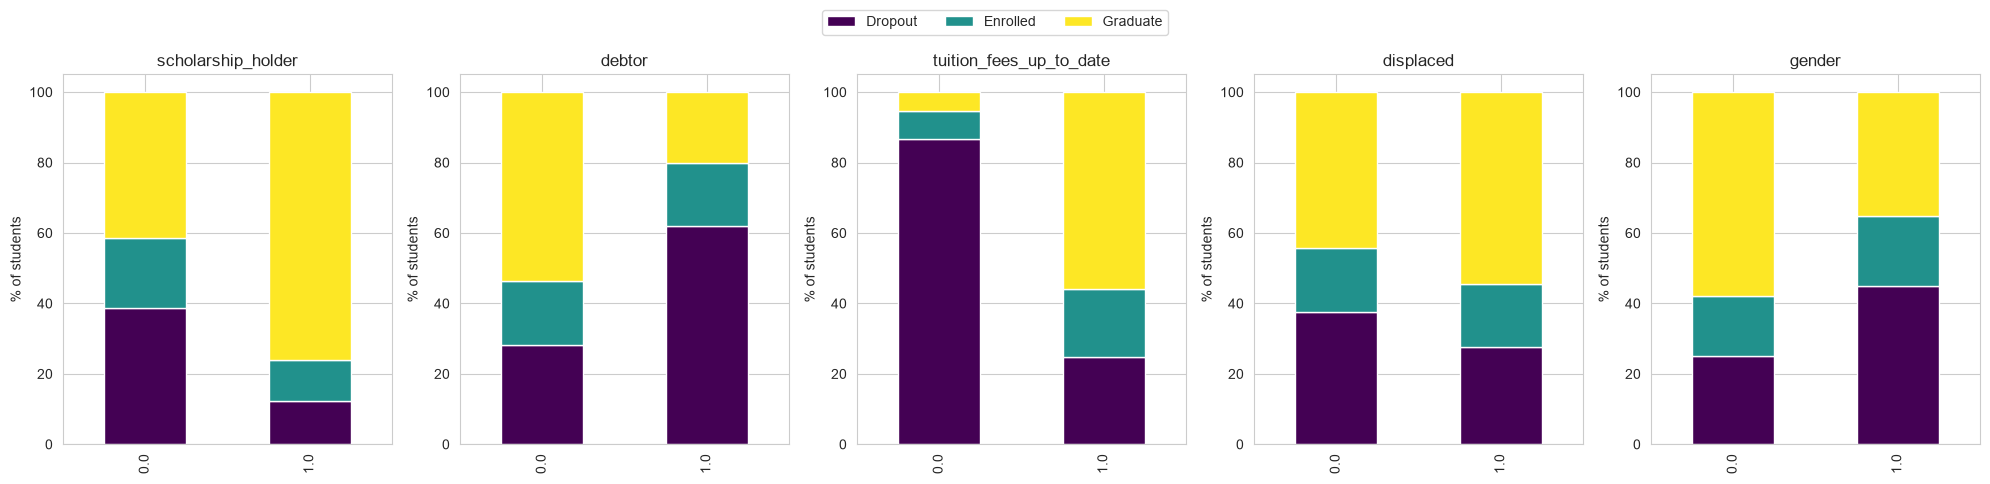

In [17]:
def target_rate_by(col, ax):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct = ct[['Dropout', 'Enrolled', 'Graduate']]
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', legend=False)
    ax.set_title(col)
    ax.set_ylabel('% of students')
    ax.set_xlabel('')

cat_cols = ['scholarship_holder', 'debtor', 'tuition_fees_up_to_date', 'displaced', 'gender']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 4.5))
for col, ax in zip(cat_cols, axes):
    target_rate_by(col, ax)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

**Reading this:** dropout rate is visibly higher for **debtors**, students **not up to date on tuition fees**, and **non-scholarship holders**, while it's lower for **displaced** students (those who study away from their home municipality — likely correlated with more committed/motivated enrollment). These socio-economic features look like real, usable signal — not just noise — which matches published findings on this dataset and is a good sanity check that the data behaves the way domain knowledge predicts.

#### Scatterplot: 1st vs 2nd semester grade

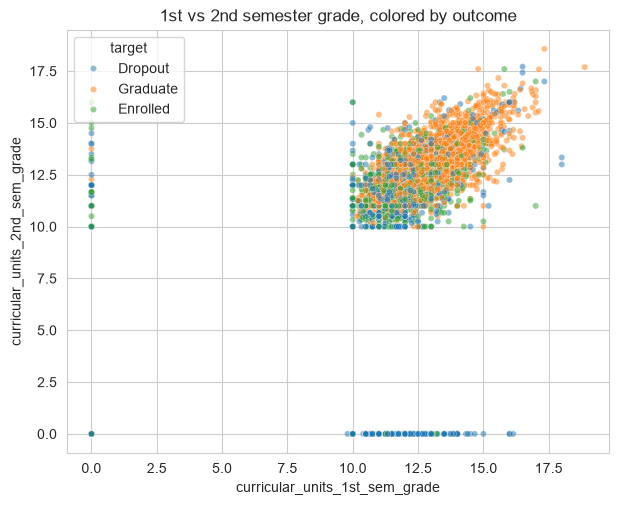

In [18]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=df, x='curricular_units_1st_sem_grade', y='curricular_units_2nd_sem_grade',
                 hue='target', alpha=0.5, s=20)
plt.title('1st vs 2nd semester grade, colored by outcome')
plt.show()

Dropout students cluster heavily near **(0, 0)** — no evaluations completed in either semester — while Graduates cluster in the upper-right. This is useful descriptive evidence of academic disengagement, but the second-semester axis is retrospective and will not enter the primary early-warning model.

#### Correlation matrix

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['target'])
list(zip(le.classes_, le.transform(le.classes_)))

[('Dropout', np.int64(0)),
 ('Enrolled', np.int64(1)),
 ('Graduate', np.int64(2))]

`LabelEncoder` turns the text labels into integers so we can include `target` in a numeric correlation matrix. Note: this ordinal encoding (0/1/2) is only useful for *exploring* correlation here — for actual modeling we'd normally either keep this as a proper multi-class target or, if we ever reduce to a binary dropout-vs-not problem, encode purposefully rather than alphabetically.

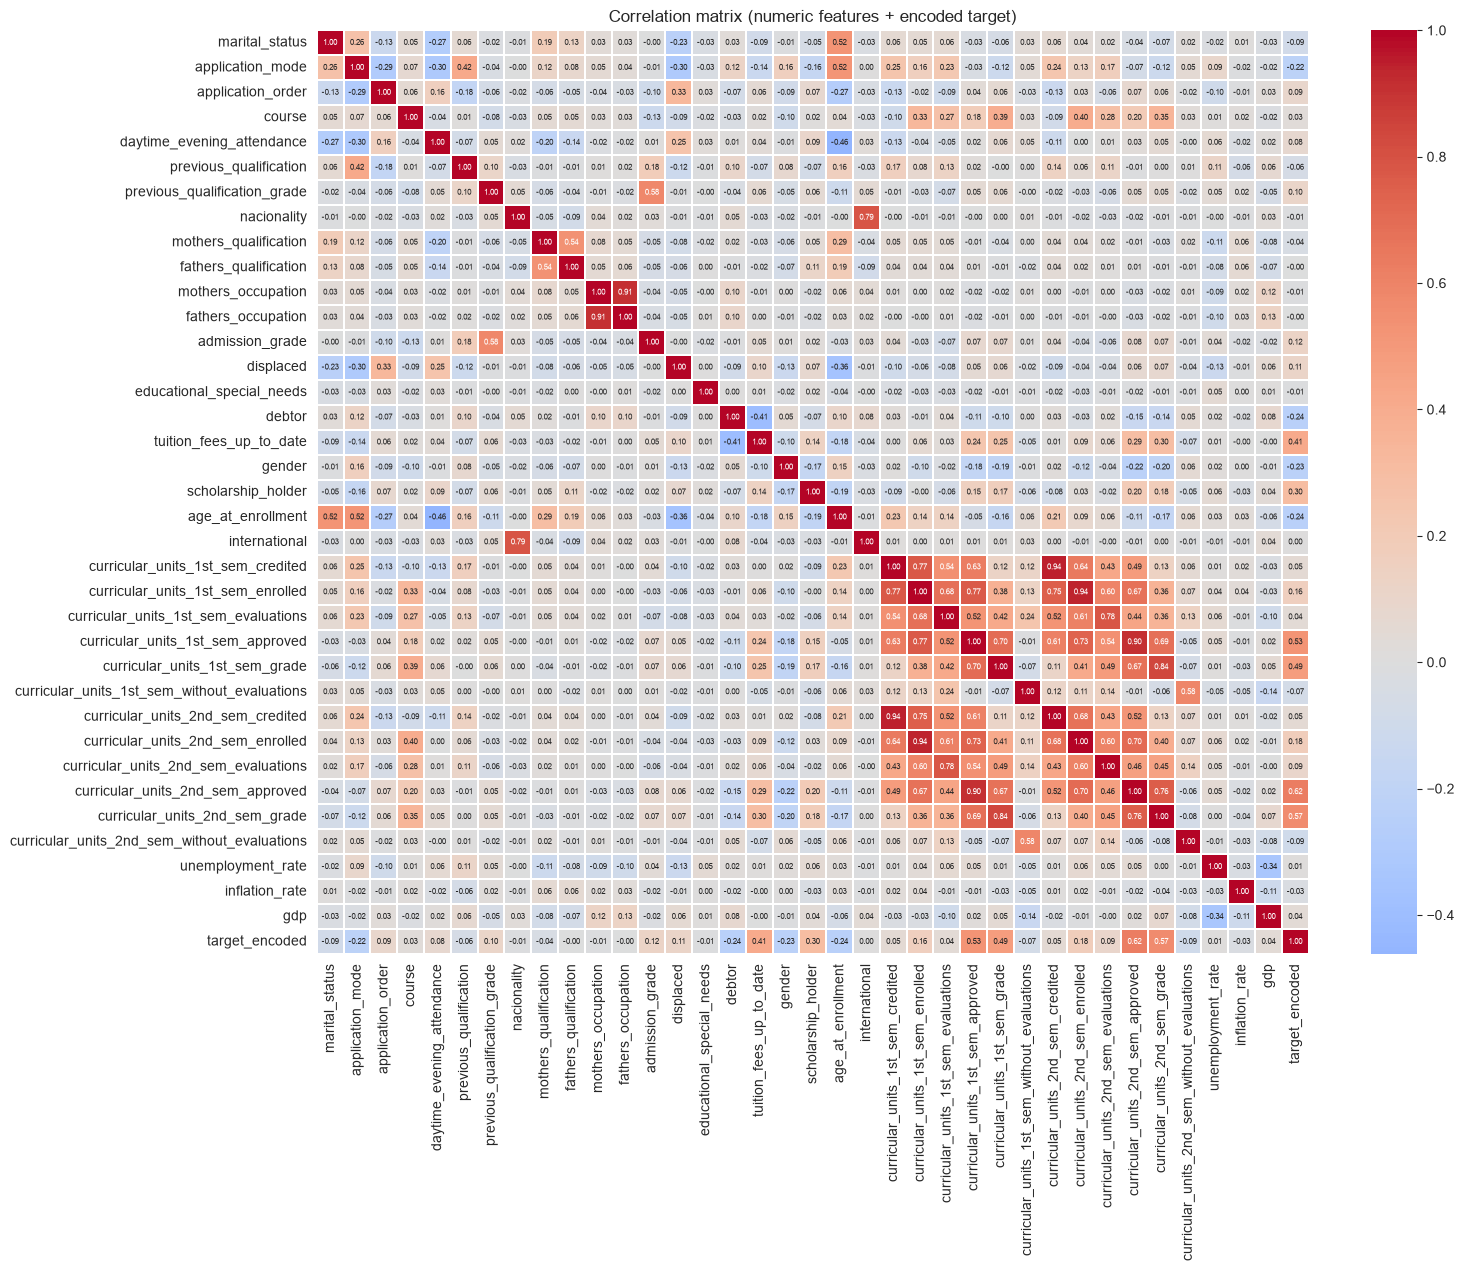

In [20]:
plt.figure(figsize=(16, 12))
corr = df.drop(columns=['target']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,annot=True, fmt='.2f', annot_kws={'size': 6})
plt.title('Correlation matrix (numeric features + encoded target)')
plt.show()

In [21]:
corr['target_encoded'].drop('target_encoded').sort_values(key=abs, ascending=False).head(12)

curricular_units_2nd_sem_approved    0.624157
curricular_units_2nd_sem_grade       0.566827
curricular_units_1st_sem_approved    0.529123
curricular_units_1st_sem_grade       0.485207
tuition_fees_up_to_date              0.409827
scholarship_holder                   0.297595
age_at_enrollment                   -0.243438
debtor                              -0.240999
gender                              -0.229270
application_mode                    -0.221747
curricular_units_2nd_sem_enrolled    0.175847
curricular_units_1st_sem_enrolled    0.155974
Name: target_encoded, dtype: float64

**Reading this:** the features most correlated with `target_encoded` are the **2nd/1st semester approved & grade columns** and **tuition_fees_up_to_date** — all strongly *positive* (higher values push toward Graduate under this exploratory encoding). `age_at_enrollment` and `debtor` correlate *negatively*. The second-semester correlations are descriptive only and cannot be used by the primary model; modeling will also replace this ordinal three-class encoding with the explicit binary target Dropout=1 / Graduate=0.

Also worth flagging: the `curricular_units_2nd_sem_*` and `curricular_units_1st_sem_*` groups are highly correlated **with each other** (multicollinearity) — something to watch for if we use a model sensitive to it (e.g. plain linear/logistic regression coefficients become hard to interpret; tree-based models handle it fine).

### Checking outliers

Same IQR-based approach as the professor's notebook: a value is flagged as an outlier if it falls more than 1.5×IQR below Q1 or above Q3.

In [22]:
def outlier_count(col, data=df):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = data[(data[col] < lower) | (data[col] > upper)][col].count()
    pct = 100 * n_outliers / len(data)
    print(f'{col:45s} {n_outliers:5d} outliers ({pct:5.1f}%)')
    return n_outliers

numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['target_encoded']).columns
for col in numeric_cols:
    outlier_count(col)

marital_status                                  505 outliers ( 11.4%)
application_mode                                  0 outliers (  0.0%)
application_order                               541 outliers ( 12.2%)
course                                          442 outliers ( 10.0%)
daytime_evening_attendance                      483 outliers ( 10.9%)
previous_qualification                          707 outliers ( 16.0%)
previous_qualification_grade                    179 outliers (  4.0%)
nacionality                                     110 outliers (  2.5%)
mothers_qualification                             0 outliers (  0.0%)
fathers_qualification                             0 outliers (  0.0%)
mothers_occupation                              182 outliers (  4.1%)
fathers_occupation                              177 outliers (  4.0%)
admission_grade                                  86 outliers (  1.9%)
displaced                                         0 outliers (  0.0%)
educational_special_

Some columns (like `age_at_enrollment`, `admission_grade`, or the `curricular_units_*` counts) will show up with a non-trivial number of IQR-outliers. Before removing anything, always ask *why* a value is extreme: a 45-year-old student or a student with 0 approved units both look like statistical outliers, but they're **plausible, real, and informative** — mature students and early dropouts are exactly who this analysis cares about. So: don't blindly drop these rows; outlier handling comes later, informed by domain reasoning, not just the IQR rule.

## 3. Key EDA takeaways

Summarizing what I found, to carry into feature engineering / modeling for the team project:

1. **Clean data:** no missing values, no duplicate rows — no imputation needed for this dataset.
2. **Imbalanced 3-class target:** ~50% Graduate / 32% Dropout / 18% Enrolled.
3. **Academic performance is the strongest descriptive signal:** first- and second-semester approved/grade variables correlate strongly with final outcome. Only first-semester variables are eligible for the primary early-warning model; second-semester variables are a retrospective upper bound and will be excluded as leakage.
4. **Socio-economic features carry real signal:** tuition-fee status, debtor status, and scholarship status all shift dropout rate visibly — important both for prediction and for the fairness/ethics discussion the course covers (these are proxies for financial hardship, so any deployed model should be checked for whether it's penalizing students for circumstances rather than choices).
5. **Age at enrollment matters:** older students at enrollment skew toward dropout — plausible given competing work/family obligations, and another feature worth an interpretable treatment (e.g. binning into age bands) rather than a raw linear effect.
6. **Multicollinearity** between 1st- and 2nd-semester feature groups — keep in mind for model/feature selection.
7. **"Zero" isn't always literal zero** for the curricular-unit grade columns — it often encodes "did not take any evaluations", which is conceptually different from "took and failed". Worth a dedicated flag feature (e.g. `no_evaluations_1st_sem`) during feature engineering.

> **Target decision:** the primary task is binary **Dropout=1 / Graduate=0**. Exclude "Enrolled" because it is an unresolved outcome, not a confirmed non-dropout. If time permits, run a clearly labelled sensitivity analysis with Enrolled retained as a separate class or grouped with non-dropout.
>
> **Feature-window note:** the 2nd-semester columns are NOT known at the end of semester 1, so a model using them is a *retrospective upper bound*, not an early-warning system. The primary early-warning model should use enrollment + 1st-semester features only.

**Suggested next steps for the project:**
- Define and save the leakage-safe enrollment-time and first-semester feature lists. Derived first-semester features such as pass rate (`approved / enrolled`) and a no-evaluations flag are allowed, but they remain historical—not mutable—at the decision point.
- Encode remaining categorical columns (`course`, `application_mode`, `mothers_qualification`, etc.) — likely one-hot or target/frequency encoding given their cardinality.
- Use the fixed stratified 70/15/15 train/validation/test split saved by `src/modeling.py`. The validation-only feasibility gate selected TabICL 2.2.0; TabPFN was not scored because its local weights require separate account/licence acceptance. Compare frozen TabICL, logistic regression, a depth-3 decision tree, and XGBoost once on the untouched test set only after the explanation protocol is fixed. Evaluate model-agnostic explanations with deletion curves, repeated-run stability, valid perturbations, and constrained counterfactuals.